# Lung Cancer Dataset: EDA and Machine Learning

This notebook explores patterns related to lung cancer survival and tests a simple logistic regression model. The main data-processing steps are stored as reusable functions in `src/analysis.py`, which makes the project easier to test and reproduce.

## 1. Import Libraries and Functions

Import plotting tools and the reusable functions used throughout the analysis.

In [1]:
import matplotlib.pyplot as plt

from src.analysis import (
    calculate_stage_survival,
    filter_stages,
    load_data,
    preprocess_data,
    smoking_counts_by_stage,
    train_and_evaluate_model,
)

## 2. Load the Dataset

`load_data()` reads the CSV file and checks that the columns required by this analysis are present. This gives a clear error if the wrong dataset is used.

In [2]:
df = load_data("lung_cancer_dataset.csv")
df.head()

,Patient_ID,Diagnosis_Year,Diagnosis_Date,WHO_Region,Country,Age,Age_Group,Gender,Smoking_Status,Cigarettes_Per_Day,...,Symptom_Count,Cancer_Type,NSCLC_Subtype,Cancer_Stage,Tumor_Size_cm,Metastasis,Diagnosis_Method,Treatment,Survival_Months,Survived
0,LC-0001,2020,2020-11-04,Western Pacific,China,46,40-49,Female,Current Smoker,28,...,5,NSCLC,Adenocarcinoma,Stage IV,6.4,Yes,MRI,Chemo + Radiation,4,No
1,LC-0002,2021,2021-12-09,Americas,Mexico,71,70-79,Male,Former Smoker,5,...,5,NSCLC,Adenocarcinoma,Stage I,2.6,No,Biopsy,Surgery + Chemotherapy,76,Yes
2,LC-0003,2017,2017-04-05,Western Pacific,Japan,53,50-59,Female,Never Smoked,0,...,3,NSCLC,Squamous Cell,Stage I,2.9,No,LDCT Screening,Surgery,69,No
3,LC-0004,2018,2018-11-24,Western Pacific,Singapore,55,50-59,Male,Current Smoker,21,...,6,NSCLC,Adenocarcinoma,Stage IV,7.0,Yes,CT Scan,Chemotherapy,9,No
4,LC-0005,2024,2024-02-19,Western Pacific,Malaysia,54,50-59,Male,Never Smoked,0,...,5,NSCLC,Adenocarcinoma,Stage III,5.8,No,Bronchoscopy,Immunotherapy,5,Yes


## 3. Inspect the Data

Review the dataset's size, data types, summary statistics, duplicate rows, unique patient IDs, and missing values before transforming it.

In [3]:
# Number of rows and columns
df.shape

(2000, 46)

In [4]:
# Data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 46 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               2000 non-null   object 
 1   Diagnosis_Year           2000 non-null   int64  
 2   Diagnosis_Date           2000 non-null   object 
 3   WHO_Region               2000 non-null   object 
 4   Country                  2000 non-null   object 
 5   Age                      2000 non-null   int64  
 6   Age_Group                2000 non-null   object 
 7   Gender                   2000 non-null   object 
 8   Smoking_Status           2000 non-null   object 
 9   Cigarettes_Per_Day       2000 non-null   int64  
 10  Years_Smoking            2000 non-null   int64  
 11  Pack_Years               2000 non-null   float64
 12  Secondhand_Smoke         2000 non-null   object 
 13  Family_History           2000 non-null   object 
 14  Occupational_Hazard     

In [5]:
# Summary statistics for numerical columns
df.describe()

,Diagnosis_Year,Age,Cigarettes_Per_Day,Years_Smoking,Pack_Years,BMI,Risk_Factor_Count,Symptom_Count,Tumor_Size_cm,Survival_Months
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2021.262000,60.749000,7.274000,8.115500,8.931150,26.544500,1.709500,3.338000,4.548050,31.755500
std,3.279746,10.337235,11.673734,12.682846,16.425992,4.045706,1.079672,1.620824,2.372069,23.838076
min,2015.000000,30.000000,0.000000,0.000000,0.000000,16.000000,0.000000,0.000000,0.500000,1.000000
25%,2019.000000,53.000000,0.000000,0.000000,0.000000,23.800000,1.000000,2.000000,2.600000,11.000000
50%,2022.000000,60.000000,0.000000,0.000000,0.000000,26.500000,2.000000,3.000000,4.300000,26.000000
75%,2024.000000,68.000000,14.000000,16.000000,12.000000,29.325000,2.000000,4.000000,6.200000,49.000000
max,2026.000000,89.000000,56.000000,59.000000,106.000000,40.000000,6.000000,9.000000,13.300000,110.000000


In [6]:
# Check for duplicate rows
df.duplicated().sum()

0

In [7]:
# Confirm that patient IDs are unique
df["Patient_ID"].nunique() == len(df)

True

In [8]:
# Check for missing values
df.isna().sum()

Patient_ID                 0
Diagnosis_Year             0
Diagnosis_Date             0
WHO_Region                 0
Country                    0
Age                        0
Age_Group                  0
Gender                     0
Smoking_Status             0
Cigarettes_Per_Day         0
Years_Smoking              0
Pack_Years                 0
Secondhand_Smoke           0
Family_History             0
Occupational_Hazard        0
Air_Pollution_Exposure     0
Alcohol_Use                0
BMI                        0
BMI_Category               0
Exercise_Frequency         0
Chronic_Lung_Disease       0
Asbestos_Exposure          0
Radon_Exposure             0
Previous_Cancer_History    0
Risk_Factor_Count          0
Genetic_Mutation           0
Coughing                   0
Shortness_of_Breath        0
Chest_Pain                 0
Coughing_Blood             0
Fatigue                    0
Weight_Loss                0
Wheezing                   0
Recurrent_Infections       0
Swallowing_Dif

## 4. Prepare Variables for Analysis

`preprocess_data()` converts `Survived` from Yes/No to 1/0 and cancer stages from Stage I-IV to 1-4. It returns a copy, so the original DataFrame is not modified accidentally.

In [9]:
df = preprocess_data(df)
df[["Survived", "Survived_num", "Cancer_Stage", "Stage_num"]].head()

,Survived,Survived_num,Cancer_Stage,Stage_num
0,No,0,Stage IV,4
1,Yes,1,Stage I,1
2,No,0,Stage I,1
3,No,0,Stage IV,4
4,Yes,1,Stage III,3


## 5. Survival Rate by Cancer Stage

Group patients by cancer stage and compare both the percentage who survived and the number of patients in each group.

In [10]:
stage_survival = calculate_stage_survival(df)
stage_survival

,Survival_Rate,Patient_Count
Cancer_Stage,,
Stage I,69.844021,577
Stage II,50.718686,487
Stage III,17.391304,460
Stage IV,5.462185,476


**Finding:** Survival rate decreases sharply as cancer stage advances. Stage I has the highest survival rate, while Stage IV has the lowest.

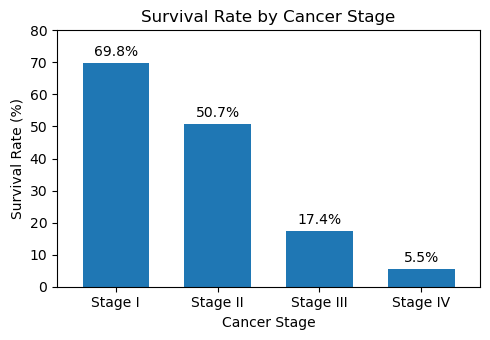

In [11]:
ax = stage_survival["Survival_Rate"].plot(
    kind="bar",
    figsize=(5, 3.5),
    width=0.65,
)

plt.xlabel("Cancer Stage")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Cancer Stage")
plt.ylim(0, 80)
plt.xticks(rotation=0)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.show()

## 6. Compare Smoking Status in Stage I and Stage IV

These stages had the largest difference in survival rates. The comparison below describes smoking-status patterns within the two groups; it does not establish that smoking status caused the stage difference.

In [12]:
stage_1_4 = filter_stages(df)
smoking_by_stage = smoking_counts_by_stage(stage_1_4)
smoking_by_stage

Smoking_Status,Current Smoker,Former Smoker,Never Smoked
Cancer_Stage,,,
Stage I,61,46,470
Stage IV,169,58,249


**Finding:** Stage IV has more current smokers, while Stage I has more patients who never smoked. This is an association in the dataset, not evidence of causation.

## 7. Tumor Size vs. Survival Months

Use a scatter plot and correlation to examine the direction and strength of the linear relationship between tumor size and survival time.

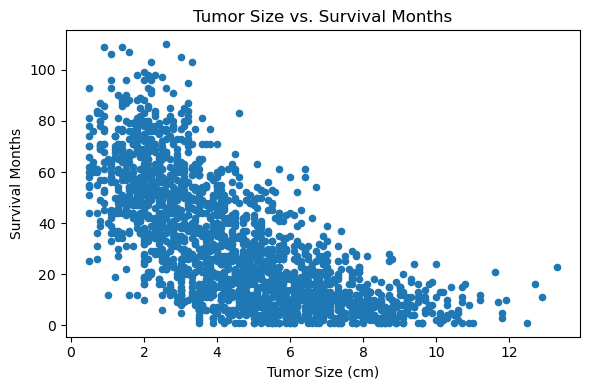

In [13]:
df.plot(
    kind="scatter",
    x="Tumor_Size_cm",
    y="Survival_Months",
    figsize=(6, 4),
)

plt.xlabel("Tumor Size (cm)")
plt.ylabel("Survival Months")
plt.title("Tumor Size vs. Survival Months")
plt.tight_layout()
plt.show()

In [14]:
tumor_survival_correlation = df["Tumor_Size_cm"].corr(df["Survival_Months"])
tumor_survival_correlation

-0.6906516545820909

**Finding:** The original dataset produced a correlation of approximately -0.69. This indicates a fairly strong negative relationship: larger tumors tend to be associated with shorter survival times in this dataset.

## 8. Machine Learning: Logistic Regression

**Question:** Can cancer stage, tumor size, and age be used to predict whether a patient survives?

The data is divided into 80% training data and 20% test data. `random_state=42` makes the split reproducible, while stratification preserves the survival-class proportions in both sets.

In [15]:
(
    model,
    y_pred,
    accuracy,
    X_train,
    X_test,
    y_train,
    y_test,
) = train_and_evaluate_model(df)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print(f"Accuracy: {accuracy:.2%}")

Training set shape: (1600, 3)
Test set shape: (400, 3)
Accuracy: 72.00%


In [16]:
# Preview the first 10 predicted survival outcomes
# 1 means survived and 0 means did not survive.
y_pred[:10]

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0])

**Model interpretation:** Accuracy is the percentage of test observations the model classified correctly. The original notebook achieved approximately 75% accuracy. This is an initial model using only three predictors, so the result should not be interpreted as a clinical tool.